In [1]:
import os

# Get project root (one level up from notebooks)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Define clean output paths
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")

# Create folders if not exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Outputs will be saved in:", OUTPUT_DIR)

Project root: C:\Users\saura\cn_project_network_security
Outputs will be saved in: C:\Users\saura\cn_project_network_security\outputs


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Try multiple possible paths automatically

possible_paths = [
    "../data/processed/ue_attack_labeled_scaled.csv",
    "data/processed/ue_attack_labeled_scaled.csv",
    "ue_attack_labeled_scaled.csv"
]

for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

print("Using data from:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Using data from: ../data/processed/ue_attack_labeled_scaled.csv
Shape: (424221, 50)


,bearer_0_dl_total_bytes,bearer_0_pdu_session_id,bearer_0_ul_total_bytes,bearer_1_dl_total_bytes,bearer_1_pdu_session_id,bearer_1_ul_total_bytes,cell_1_cqi,cell_1_dl_bitrate,cell_1_dl_err,cell_1_dl_mcs,...,cell_3_ul_bitrate,cell_3_ul_err,cell_3_ul_tx,cell_3_p_ue,cell_3_ul_mcs,cell_3_ul_path_loss,cell_3_ul_phr,ul_retx_max,dl_retx_max,attack_label
0,-0.376399,-0.678566,-0.362117,-0.295402,-0.450081,-0.31859,0.279174,-0.403038,-0.005953,0.183453,...,-0.375857,-0.061983,-0.399326,-0.002687,-0.026373,-0.019898,-0.065749,-0.522684,-0.551431,0
1,-0.376399,-0.678566,-0.362117,-0.295402,-0.450081,-0.31859,0.279174,-0.403093,-0.005953,0.183453,...,-0.375857,-0.061983,-0.399326,-0.002687,-0.026373,-0.019898,-0.065749,-0.522684,-0.535272,0
2,-0.376399,-0.678566,-0.362117,-0.295402,-0.450081,-0.31859,0.279174,-0.402346,-0.005953,0.202907,...,-0.375857,-0.061983,-0.399326,-0.002687,-0.026373,-0.019898,-0.065749,-0.522684,-0.535272,0
3,-0.376399,-0.678566,-0.362117,-0.295402,-0.450081,-0.31859,0.279174,-0.403293,-0.005953,0.183453,...,-0.375857,-0.061983,-0.399326,-0.002687,-0.026373,-0.019898,-0.065749,-0.522684,-0.502955,0
4,-0.376399,-0.678566,-0.362117,-0.295402,-0.450081,-0.31859,0.279174,-0.403111,-0.005953,0.183453,...,-0.375857,-0.061983,-0.399326,-0.002687,-0.026373,-0.019898,-0.065749,-0.522684,-0.535272,0


In [4]:
print("\nColumns:\n", df.columns)

print("\nMissing values:", df.isnull().sum().sum())

# Ensure no NaNs
df = df.dropna()

print("After cleaning:", df.shape)


Columns:
 Index(['bearer_0_dl_total_bytes', 'bearer_0_pdu_session_id',
       'bearer_0_ul_total_bytes', 'bearer_1_dl_total_bytes',
       'bearer_1_pdu_session_id', 'bearer_1_ul_total_bytes', 'cell_1_cqi',
       'cell_1_dl_bitrate', 'cell_1_dl_err', 'cell_1_dl_mcs', 'cell_1_dl_tx',
       'cell_1_epre', 'cell_1_initial_ta', 'cell_1_p_ue', 'cell_1_pusch_snr',
       'cell_1_ri', 'cell_1_turbo_decoder_avg', 'cell_1_turbo_decoder_max',
       'cell_1_turbo_decoder_min', 'cell_1_ul_bitrate', 'cell_1_ul_err',
       'cell_1_ul_mcs', 'cell_1_ul_path_loss', 'cell_1_ul_phr', 'cell_1_ul_tx',
       'dl_bitrate', 'ran_ue_id', 'ul_bitrate', 'cell_3_cqi',
       'cell_3_dl_bitrate', 'cell_3_dl_err', 'cell_3_dl_mcs', 'cell_3_dl_tx',
       'cell_3_epre', 'cell_3_initial_ta', 'cell_3_pusch_snr', 'cell_3_ri',
       'cell_3_turbo_decoder_avg', 'cell_3_turbo_decoder_max',
       'cell_3_turbo_decoder_min', 'cell_3_ul_bitrate', 'cell_3_ul_err',
       'cell_3_ul_tx', 'cell_3_p_ue', 'cell_3_ul_mcs', 

In [5]:
# Try to auto-detect target column

possible_targets = ["attack_label", "label", "target"]

for col in possible_targets:
    if col in df.columns:
        TARGET = col
        break

print("Using target column:", TARGET)

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("\nClass distribution:\n", y.value_counts())

Using target column: attack_label

Class distribution:
 attack_label
0    397597
1     26624
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (339376, 49)
Test shape: (84845, 49)


In [7]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train_res))

After SMOTE: [318077 318077]


In [8]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_res, y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [9]:
y_probs = model.predict_proba(X_test)[:, 1]
y_pred = (y_probs > 0.5).astype(int)

print("=== Default Threshold (0.5) ===\n")
print(classification_report(y_test, y_pred))

=== Default Threshold (0.5) ===

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     79520
           1       0.89      0.99      0.94      5325

    accuracy                           0.99     84845
   macro avg       0.95      0.99      0.97     84845
weighted avg       0.99      0.99      0.99     84845



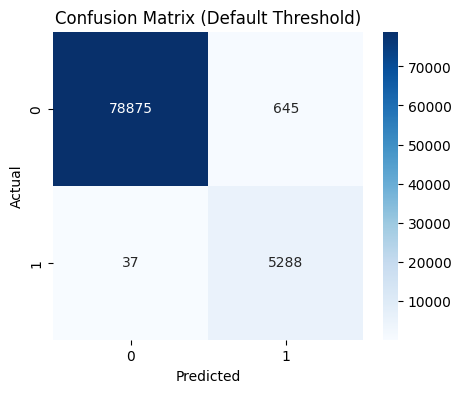

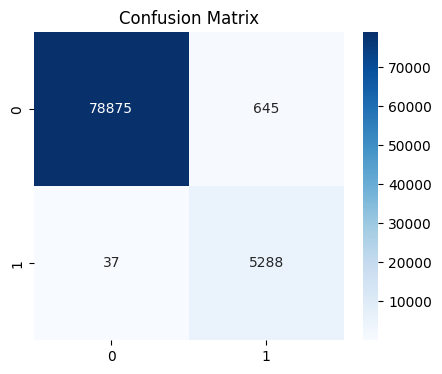

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Default Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(FIG_DIR, "confusion_matrix.png"))
plt.show()

### THRESHOLD OPTIMIZATION

In [11]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_idx])

Best Threshold: 0.7081047
Best F1 Score: 0.957287130497586


In [12]:
y_pred_opt = (y_probs > best_threshold).astype(int)

print("=== Optimized Threshold Results ===\n")
print(classification_report(y_test, y_pred_opt))

=== Optimized Threshold Results ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79520
           1       0.94      0.97      0.96      5325

    accuracy                           0.99     84845
   macro avg       0.97      0.98      0.98     84845
weighted avg       0.99      0.99      0.99     84845



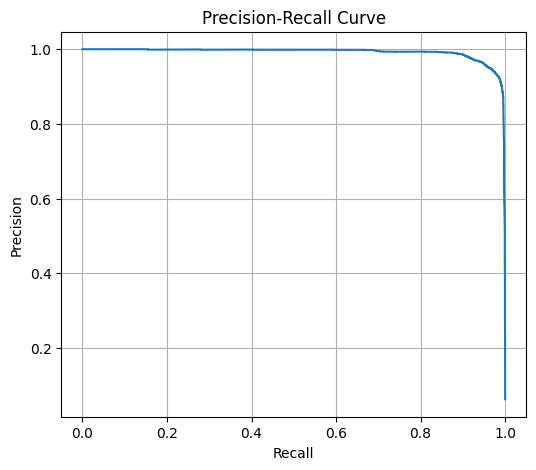

<Figure size 640x480 with 0 Axes>

In [18]:
plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

plt.savefig(os.path.join(FIG_DIR, "precision_recall_curve.png"))
plt.show()

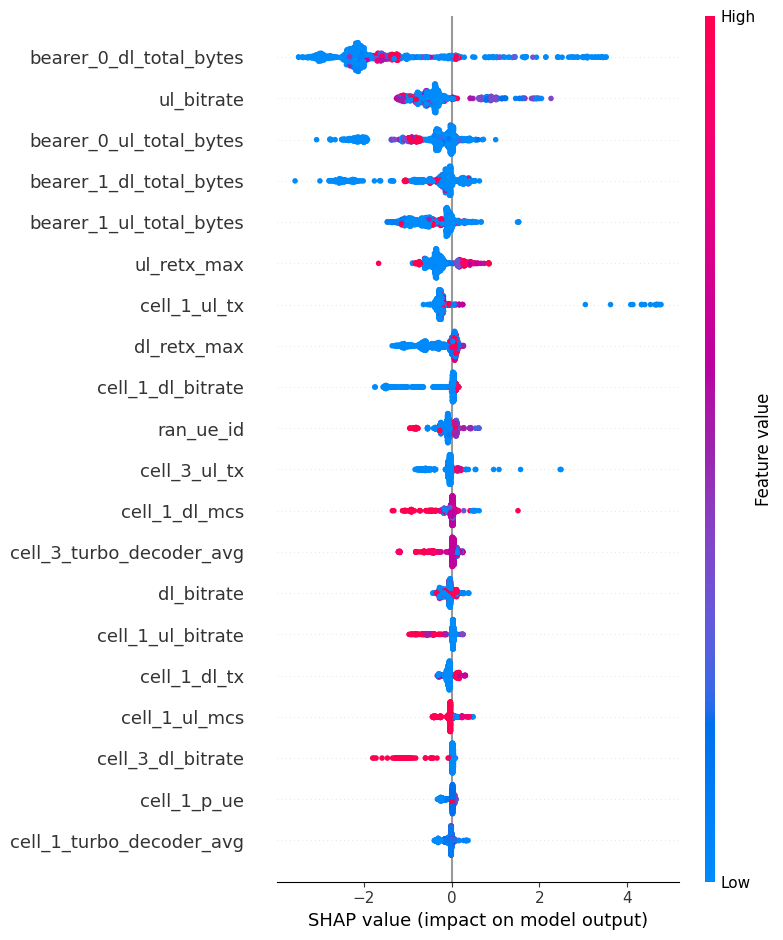

<Figure size 640x480 with 0 Axes>

In [19]:
# Use smaller sample for speed
sample_X = X_test.sample(1000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample_X)

shap.summary_plot(shap_values, sample_X)
plt.savefig(os.path.join(FIG_DIR, "shap_summary.png"))
plt.show()

In [16]:
np.save(os.path.join(PRED_DIR, "y_probs.npy"), y_probs)
np.save(os.path.join(PRED_DIR, "y_test.npy"), y_test)

X_test.to_csv(os.path.join(PRED_DIR, "X_test.csv"), index=False)

In [15]:
import joblib

joblib.dump(model, os.path.join(MODEL_DIR, "xgb_model.pkl"))

['C:\\Users\\saura\\cn_project_network_security\\outputs\\models\\xgb_model.pkl']